In [10]:
# Import libraries
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

print("✅ Libraries ready!")

✅ Libraries ready!


In [11]:
from google.colab import files
uploaded = files.upload()

df = pd.read_csv(list(uploaded.keys())[0])
df['transaction_date'] = pd.to_datetime(df['transaction_date'])
df['revenue'] = df['unit_price'] * df['transaction_qty']

print("✅ Data loaded!", df.shape)

Saving archive.csv to archive.csv
✅ Data loaded! (149116, 12)


In [12]:
df.sort_values('revenue', ascending=False).head(5)

,transaction_id,transaction_date,transaction_time,transaction_qty,store_id,store_location,product_id,unit_price,product_category,product_type,product_detail,revenue
133337,133674,2023-06-17,10:41:11,8,8,Hell's Kitchen,8,45.0,Coffee beans,Premium Beans,Civet Cat,360.0
148702,149043,2023-06-30,11:18:31,8,8,Hell's Kitchen,8,45.0,Coffee beans,Premium Beans,Civet Cat,360.0
133407,133744,2023-06-17,11:18:31,8,8,Hell's Kitchen,8,45.0,Coffee beans,Premium Beans,Civet Cat,360.0
68981,69151,2023-04-17,11:18:31,8,8,Hell's Kitchen,8,45.0,Coffee beans,Premium Beans,Civet Cat,360.0
97979,98233,2023-05-17,09:05:20,8,8,Hell's Kitchen,8,45.0,Coffee beans,Premium Beans,Civet Cat,360.0


In [13]:
daily_revenue = df.groupby('transaction_date')['revenue'].sum()
daily_revenue.sort_values(ascending=False).head(5)

,revenue
transaction_date,
2023-06-19,6403.91
2023-06-13,6189.36
2023-06-08,6151.59
2023-06-17,6117.60
2023-06-18,6026.09


In [14]:
df.groupby('store_location')['revenue'].sum()

,revenue
store_location,
Astoria,232243.91
Hell's Kitchen,236511.17
Lower Manhattan,230057.25


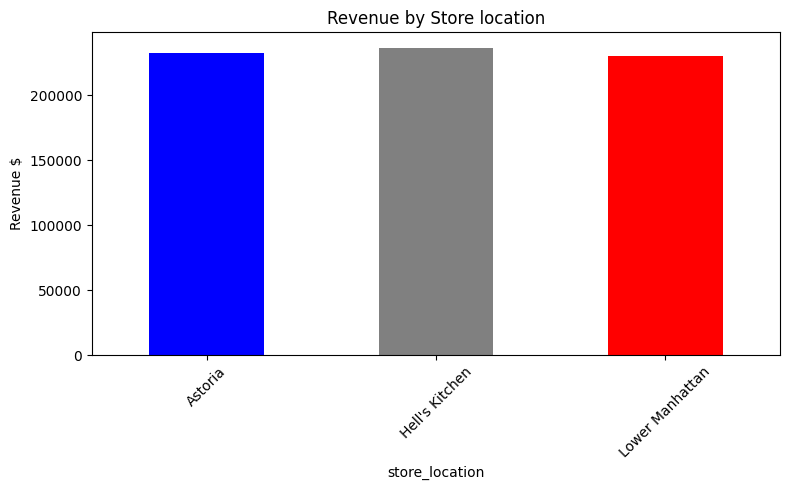

In [15]:
store_revenue = df.groupby('store_location')['revenue'].sum()
store_revenue.plot(kind='bar', color=['blue', 'grey','red'], figsize=(8,5))
plt.title('Revenue by Store location')
plt.ylabel('Revenue $')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [16]:
df['month'] = pd.to_datetime(df['transaction_date']).dt.month

monthly_store = df.groupby(['store_location', 'month'])['revenue'].sum()
print(monthly_store)

store_location   month
Astoria          1        27313.66
                 2        25105.34
                 3        32835.43
                 4        39477.61
                 5        52428.76
                 6        55083.11
Hell's Kitchen   1        27820.65
                 2        25719.80
                 3        33110.57
                 4        40304.14
                 5        52598.93
                 6        56957.08
Lower Manhattan  1        26543.43
                 2        25320.05
                 3        32888.68
                 4        39159.33
                 5        51700.07
                 6        54445.69
Name: revenue, dtype: float64


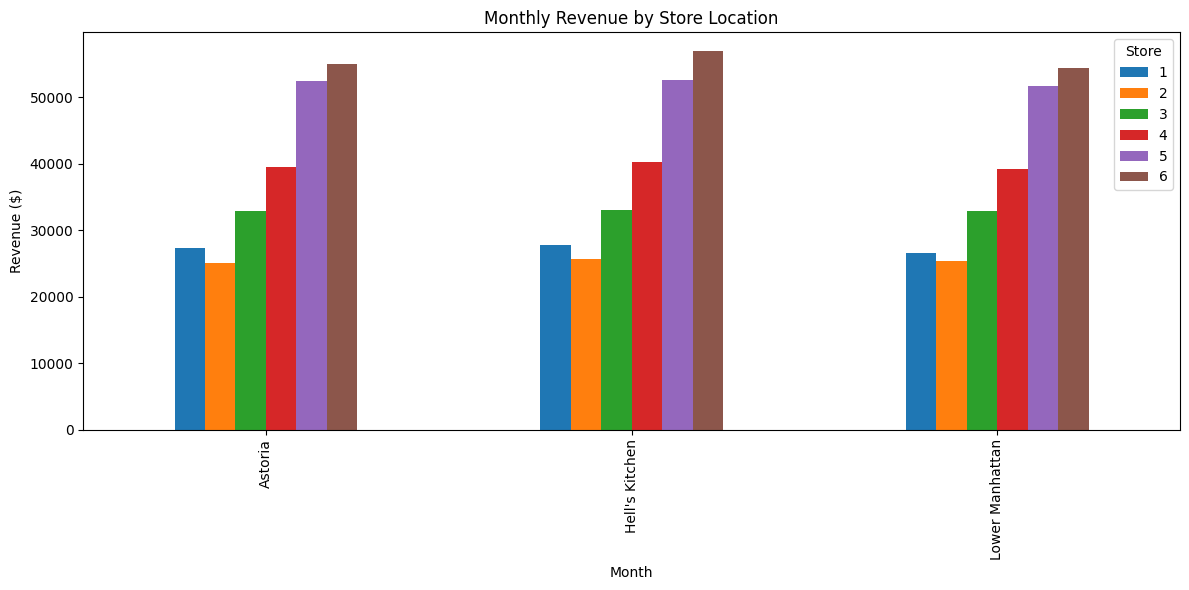

In [17]:
monthly_store.unstack().plot(kind='bar', figsize=(12,6))
plt.title('Monthly Revenue by Store Location')
plt.ylabel('Revenue ($)')
plt.xlabel('Month')
plt.legend(title='Store')
plt.tight_layout()
plt.show()

In [18]:
best_product = df.groupby(['store_location', 'product_type'])['transaction_qty'].sum()
print(best_product)

store_location   product_type         
Astoria          Barista Espresso         7345
                 Biscotti                 1955
                 Black tea                  85
                 Brewed Black tea         5891
                 Brewed Chai tea          9306
                                          ... 
Lower Manhattan  Premium Beans              93
                 Premium brewed coffee    4156
                 Regular syrup            3268
                 Scone                    3656
                 Sugar free syrup         1441
Name: transaction_qty, Length: 87, dtype: int64


In [19]:
best_per_store = df.groupby(['store_location', 'product_type'])['transaction_qty'].sum()
best_per_store = best_per_store.groupby('store_location').idxmax()
print(best_per_store)

store_location
Astoria                          (Astoria, Brewed Chai tea)
Hell's Kitchen           (Hell's Kitchen, Barista Espresso)
Lower Manhattan    (Lower Manhattan, Gourmet brewed coffee)
Name: transaction_qty, dtype: object


In [20]:
daily = df.groupby(['transaction_date', 'store_location'])['revenue'].sum()

avg_daily = daily.groupby('store_location').mean()
print(avg_daily)

store_location
Astoria            1283.115525
Hell's Kitchen     1306.691547
Lower Manhattan    1271.034530
Name: revenue, dtype: float64


In [21]:
!pip install --upgrade fpdf2 -q
import fpdf
print(f"FPDF version: {fpdf.__version__}")

FPDF version: 2.8.7


In [26]:
import pandas as pd
from fpdf import FPDF
from fpdf.enums import XPos, YPos
from google.colab import files
import os

# 1. Ensure Data is Loaded and Available
try:
    # Check if df exists in global scope, otherwise try to load it
    if 'df' not in globals() or df is None:
        if os.path.exists('archive.csv'):
            df = pd.read_csv('archive.csv')
            df['transaction_date'] = pd.to_datetime(df['transaction_date'])
            df['revenue'] = df['unit_price'] * df['transaction_qty']
        else:
            print('Please upload archive.csv using the folder icon on the left.')
            df = None

    if df is not None and not df.empty:
        # 2. Recalculate Metrics
        store_revenue = df.groupby('store_location')['revenue'].sum()
        best_per_store = df.groupby(['store_location', 'product_type'])['transaction_qty'].sum().groupby('store_location').idxmax()
        daily = df.groupby(['transaction_date', 'store_location'])['revenue'].sum()
        avg_daily = daily.groupby('store_location').mean()

        # 3. Generate PDF
        pdf = FPDF()
        pdf.add_page()
        available_width = pdf.w - pdf.l_margin - pdf.r_margin

        pdf.set_font('Helvetica', 'B', 24)
        pdf.cell(0, 20, 'Franchise Performance Analysis', align='C', new_x=XPos.LMARGIN, new_y=YPos.NEXT)
        pdf.set_font('Helvetica', '', 14)
        pdf.cell(0, 10, 'Multi-Store Business Report', align='C', new_x=XPos.LMARGIN, new_y=YPos.NEXT)
        pdf.ln(10)

        pdf.set_font('Helvetica', 'B', 16)
        pdf.cell(0, 10, 'Total Revenue by Store:', new_x=XPos.LMARGIN, new_y=YPos.NEXT)
        pdf.set_font('Helvetica', '', 13)
        for store, revenue in store_revenue.items():
            pdf.multi_cell(available_width, 10, f'{store}: ${revenue:,.2f}', align='L')
        pdf.ln(5)

        pdf.set_font('Helvetica', 'B', 16)
        pdf.cell(0, 10, 'Best Selling Product per Store:', new_x=XPos.LMARGIN, new_y=YPos.NEXT)
        pdf.set_font('Helvetica', '', 13)
        for store, (s_loc, product_type) in best_per_store.items():
            pdf.multi_cell(available_width, 10, f'{store}: {product_type}', align='L')
        pdf.ln(5)

        pdf.set_font('Helvetica', 'B', 16)
        pdf.cell(0, 10, 'Average Daily Revenue:', new_x=XPos.LMARGIN, new_y=YPos.NEXT)
        pdf.set_font('Helvetica', '', 13)
        for store, avg_rev in avg_daily.items():
            pdf.multi_cell(available_width, 10, f'{store}: ${avg_rev:,.0f}', align='L')

        pdf.output('franchise_report.pdf')
        print('✅ PDF generated successfully!')

except Exception as e:
    print(f'An error occurred: {e}')

✅ PDF generated successfully!


In [25]:
import pandas as pd
from google.colab import files
import os

# Request file upload if missing
if not os.path.exists('archive.csv'):
    print("Please upload 'archive.csv' to continue.")
    uploaded = files.upload()
    filename = list(uploaded.keys())[0]
    # Rename if necessary to match expected 'archive.csv'
    if filename != 'archive.csv':
        os.rename(filename, 'archive.csv')

# Load and prepare data
df = pd.read_csv('archive.csv')
df['transaction_date'] = pd.to_datetime(df['transaction_date'])
df['revenue'] = df['unit_price'] * df['transaction_qty']
print('✅ Dataframe initialized and ready for processing.')

✅ Dataframe initialized and ready for processing.
